In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
)

Downloading bucket files: 73819124 / 73819124 complete

Downloading bytes: 73819124 / 73819124 complete

In [2]:
reader = scarf.CrH5Reader(f'{dataset}/data.h5')
reader.nCells, reader.nFeatures

(5025, 33538)

In [3]:
writer = scarf.CrToZarr(
    reader,
    zarr_loc=f'{dataset}/data.zarr',
)
writer.dump()

Writing counts: 3 / 3 complete

In [4]:
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    min_features_per_cell=10
)

Computing RNA initialization statistics: 3 / 3 complete

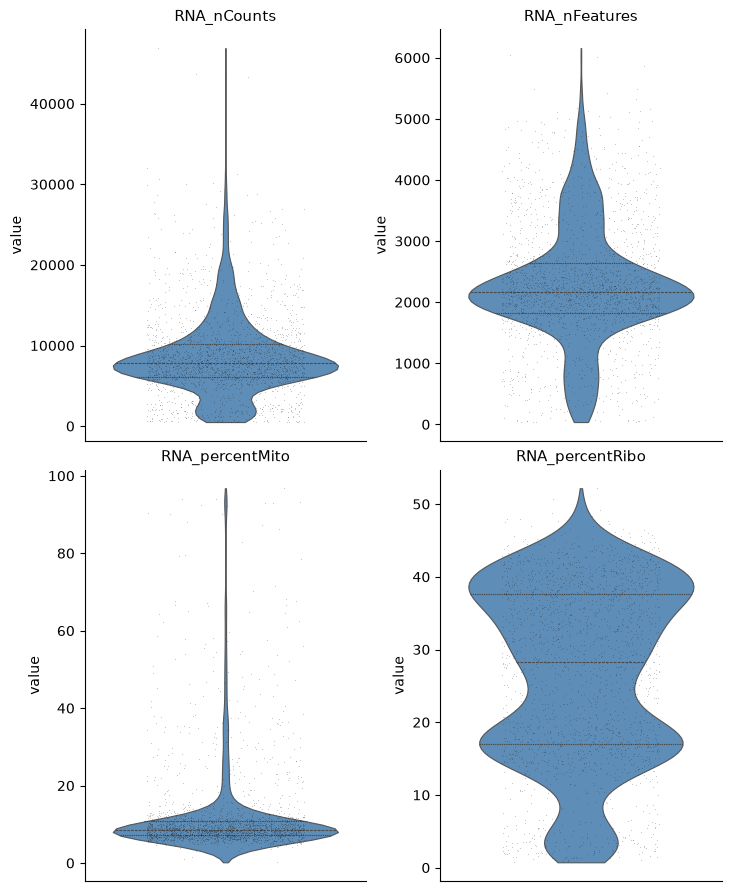

In [5]:
qc_cols = [
    c for c in (
        'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo'
    )
    if c in ds.cells.columns
]
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
)

In [6]:
n_before = int(ds.cells.fetch_all('I').sum())
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito'],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0]
)
n_after = int(ds.cells.fetch_all('I').sum())
print(f'Active cells before filter: {n_before}')
print(f'Active cells after filter: {n_after}')

Active cells before filter: 5025
Active cells after filter: 3940


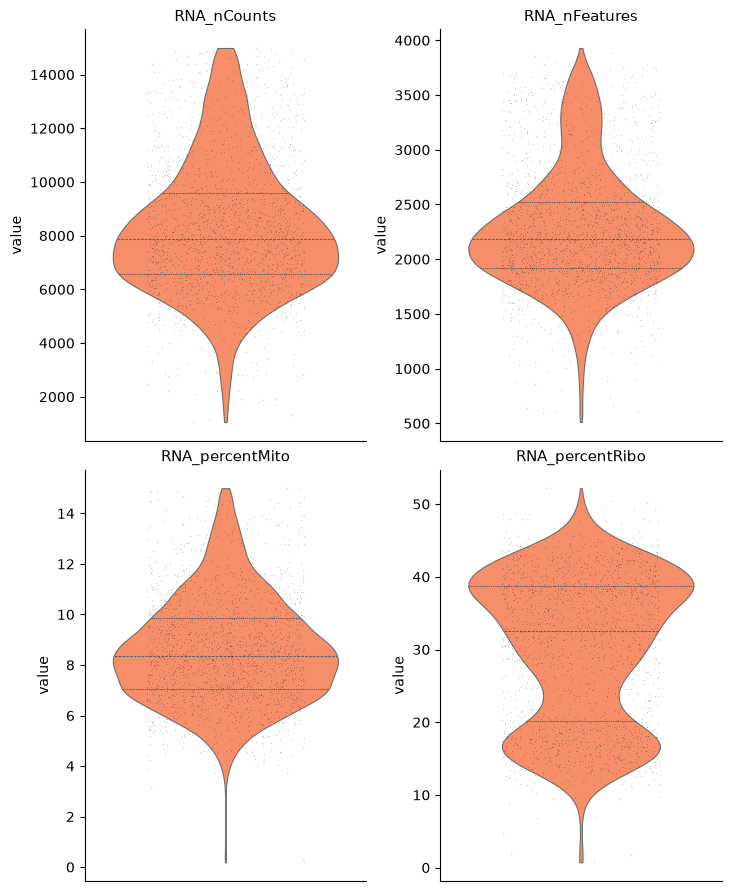

In [7]:
ds.plots.distribution(
    keys=qc_cols,
    kind='violin',
    max_points=2000,
    color='coral',
)

Computing RNA feature statistics: 6 / 6 complete

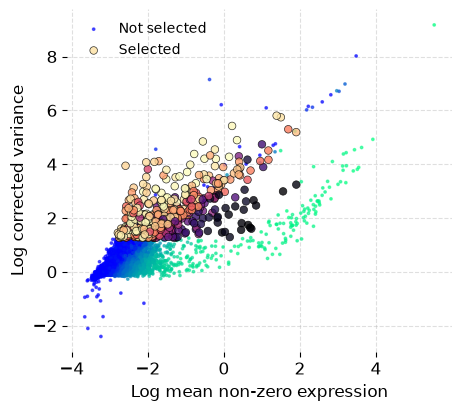

Selected genes: 498


In [8]:
ds.mark_hvgs(
    min_cells=20,
    top_n=500,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=True,
)
print('Selected genes:', int(ds.RNA.feats.fetch_all('I__hvgs').sum()))

In [9]:
ds.run_normalization(feat_key='hvgs')

Writing data: 1 / 1 complete

ArtifactRef(assay='RNA', kind='normalized', artifact_id='46a948592b39...')

In [10]:
ds.run_pca(dims=15)

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

ArtifactRef(assay='RNA', kind='reduction', artifact_id='807538861ded...')

In [11]:
ds.build_embedding_initialization()
ds.build_ann_index()
ds.query_neighbors(k=11)
ds.build_connectivity_map()

ds.load_graph()

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 43340 stored elements and shape (3940, 3940)>

In [12]:
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP: 250 / 250 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='134169f080b2...')

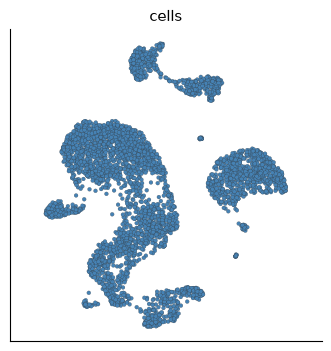

In [13]:
ds.plots.embedding(layout_key='RNA_UMAP')

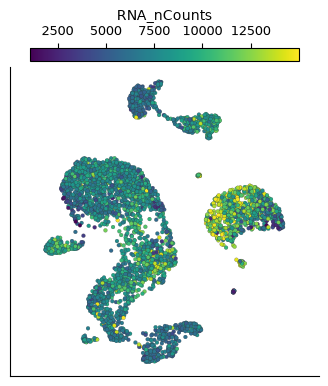

In [14]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
)

In [15]:
ds.run_leiden_clustering(resolution=0.5)
ds.cells.to_pandas_dataframe(
    columns=['RNA_leiden_cluster'],
    key='I'
)['RNA_leiden_cluster'].value_counts().sort_index()

RNA_leiden_cluster
1     1261
2      699
3      670
4      318
5      299
6      252
7      246
8      143
9       25
10      15
11      12
Name: count, dtype: int64

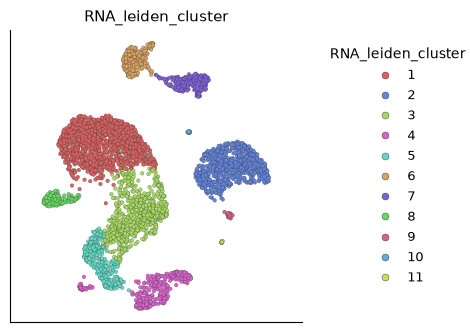

In [16]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)

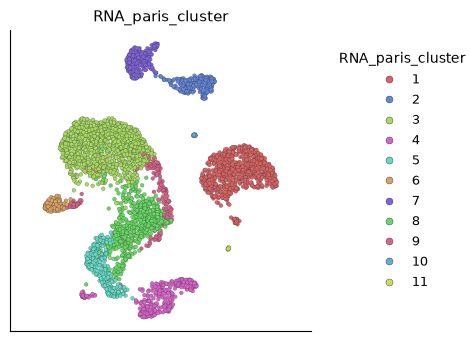

In [17]:
paris = ds.run_paris_clustering()
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=paris.label_key,
)

In [18]:
ds.run_marker_search(group_key='RNA_leiden_cluster')

Finding markers: 1 / 1 complete

Aggregating marker values per group: 2 / 2 complete

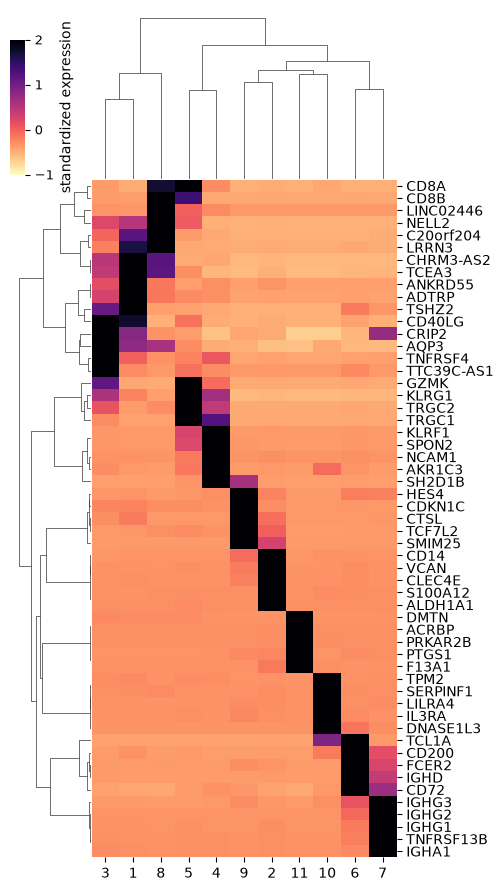

In [19]:
ds.plots.marker_heatmap(
    group_key='RNA_leiden_cluster',
    topn=5,
    figsize=(5, 9)
)

In [20]:
df = ds.get_markers(
    group_key='RNA_leiden_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
df.head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,ADTRP,10307,0.65392,0.04279,0.00279,0.23870,0.02202,15.33521,2.476793e-109,0.60948,1.832955e-107
1,1,TSHZ2,29849,0.57190,0.07198,0.01066,0.32593,0.04927,6.75262,4.094205e-123,0.63942,3.677832e-121
2,1,ANKRD55,8924,0.56296,0.02191,0.00114,0.14750,0.00971,19.15811,4.492931e-72,0.56922,1.649679e-70
3,1,CHRM3-AS2,3027,0.50922,0.06777,0.00821,0.38303,0.05786,8.24963,6.665595e-152,0.66602,8.278669e-150
4,1,TCEA3,487,0.50281,0.03187,0.00409,0.21015,0.03285,7.79982,7.034657e-76,0.59004,2.737766e-74


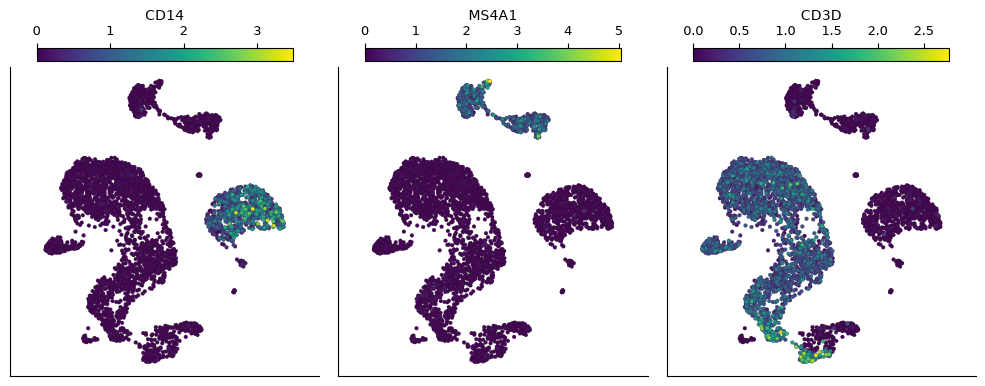

In [21]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=['CD14', 'MS4A1', 'CD3D'],
    n_columns=3,
    sort_values=True,
)